In [818]:
import qutip

import numpy as np
np.set_printoptions(formatter={'float': '{: 0.2f}'.format})
import matplotlib.pyplot as plt

from qutip import sigmax, sigmay, sigmaz, qeye
from qutip import bra, ket, ket2dm, tensor, commutator
from qutip.qip.operations import snot, cnot, rx, ry, rz

np.set_printoptions(precision=2, suppress=True)
def cldisp(obj):
    """Formats a QuTiP object for better display without altering values."""
    full_matrix = obj.full()  # Get the full NumPy array
    rounded_matrix = np.vectorize(lambda x: complex(round(x.real, 2), round(x.imag, 2)))(full_matrix)
    return qutip.Qobj(rounded_matrix, dims=obj.dims) 
                    
#some convenient aliases
pi = np.pi
sq2 = np.sqrt(2)
j = complex(0,1)
sqj = np.sqrt(j)
E = qeye(2)
Ix = sigmax()/2
Iy = sigmay()/2
Iz = sigmaz()/2

###  Define pulses

In [819]:
p1x = (-1j*np.pi/4*tensor(sigmax(),qeye(2))).expm()
p1y = (-1j*np.pi/4*tensor(sigmay(),qeye(2))).expm()

p1x_4 = (-1j*np.pi/8*tensor(sigmax(),qeye(2))).expm()
p1y_4 = (-1j*np.pi/8*tensor(sigmay(),qeye(2))).expm()

p1x_4_m = (1j*np.pi/8*tensor(sigmax(),qeye(2))).expm()
p1y_4_m = (1j*np.pi/8*tensor(sigmay(),qeye(2))).expm()

p2x = (-1j*np.pi/4*tensor(qeye(2),sigmax())).expm()
p2y = (-1j*np.pi/4*tensor(qeye(2),sigmay())).expm()

p2x_4 = (-1j*np.pi/8*tensor(qeye(2),sigmax())).expm()
p2y_4 = (-1j*np.pi/8*tensor(qeye(2),sigmay())).expm()

p2x_4_m = (1j*np.pi/8*tensor(qeye(2),sigmax())).expm()
p2y_4_m = (1j*np.pi/8*tensor(qeye(2),sigmay())).expm()

X1 = (-1j*np.pi/2*tensor(sigmax(),qeye(2))).expm()
X2 = (-1j*np.pi/2*tensor(qeye(2),sigmax())).expm()

H1 = p1y_4_m*X1*p1y_4
H2 = p2y_4_m*X2*p2y_4


In [820]:
p1z=(-1j*np.pi/4*tensor(sigmaz(),qeye(2))).expm()
p2z=(-1j*np.pi/4*tensor(qeye(2),sigmaz())).expm()

In [821]:
uzz=(-1j*np.pi/4*tensor(sigmaz(),sigmaz())).expm()

### Define density matrix and detection:

In [822]:
# thermal state
rho0 = - 2 * ( - tensor(E,Iz) - 4 * tensor(Iz,E) )
print(rho0)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 5.  0.  0.  0.]
 [ 0.  3.  0.  0.]
 [ 0.  0. -3.  0.]
 [ 0.  0.  0. -5.]]


In [823]:
# measurement operators
#   define these to "include the pi/2 readout pulse" - i.e. just measure in z-basis
#   this allows partial traces to compute the difference E_beta - E_alpha
obsH = tensor( sigmaz(), E )
obsC = tensor( E, sigmaz() )

In [824]:
(obsH * rho0).ptrace(1)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[8. 0.]
 [0. 8.]]

In [825]:
(obsH * rho0).ptrace(0).diag()

array([8., 8.])

In [826]:
(obsC* rho0).ptrace(1)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[2. 0.]
 [0. 2.]]

In [827]:
(obsC* rho0).ptrace(1).diag()

array([2., 2.])

In [828]:
# how to use

#   measure H / trace over H 
print( ( obsH * rho0 ).ptrace(1).diag() )
#   measure C / trace over H [0]
print( ( obsC * rho0 ).ptrace(0).diag() )
# N.B.  ptrace(1) returns rho^I, i.e. it traces over 0 = H 

# NOTE - The printed order of peaks are as seen in the spectrometer [ higher energy, lower energy ]
#        (one can reverse the printed order with [::-1] if desired) 

[8. 8.]
[2. 2.]


### Spectra

In [829]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import tensor, sigmaz, sigmap, qeye

def detection_signal(t_array, rho, T2=None):
    """
    Compute the time-domain signals for both proton (H) and carbon (C)
    using the evolving sigma⁺ detection operator.
    
    Parameters:
        t_array : array of time points for the evolution.
        rho     : initial two-spin density matrix (Qobj with dims [[2,2],[2,2]]).
        T2      : relaxation time for exponential decay (if None, no decay is applied).
        
    Returns:
        signalH : array of complex detection signals for proton (H).
        signalC : array of complex detection signals for carbon (C).
    """
    E = qeye(2)
    
    signalH = np.zeros(len(t_array), dtype=complex)
    signalC = np.zeros(len(t_array), dtype=complex)
    
    for idx, t in enumerate(t_array):
        # Example: Uzz(t) = exp(-i * (215*pi/4 * sigmaz ⊗ sigmaz) * t)
        Uzz = (-1j * 215 * np.pi/4 * tensor(sigmaz(), sigmaz()) * t).expm()
        
        # Evolve the sigma⁺ operator:
        # Proton: sigma⁺ on the first spin
        obsO_H = Uzz.dag() * tensor(sigmap(), E) * Uzz
        # Carbon: sigma⁺ on the second spin
        obsO_C = Uzz.dag() * tensor(E, sigmap()) * Uzz
        
        # Apply exponential decay if T2 is provided
        decay = np.exp(-t/T2) if T2 is not None else 1
        
        # Compute the detection signals using QuTiP's .tr() method
        signalH[idx] = (obsO_H * p1y * rho * p1y.dag()).tr() * decay
        signalC[idx] = (obsO_C * p2y * rho * p2y.dag()).tr() * decay
        
    return signalH, signalC

def compute_spectrum(signal, t_array):
    """
    Compute the Fourier Transform of a time-domain signal.
    
    Parameters:
        signal  : time-domain signal (numpy array).
        t_array : time points corresponding to the signal.
        
    Returns:
        freq     : frequency axis (numpy array).
        spectrum : Fourier-transformed signal (numpy array).
    """
    dt = t_array[1] - t_array[0]
    spectrum = np.fft.fftshift(np.fft.fft(signal))
    freq = np.fft.fftshift(np.fft.fftfreq(len(t_array), d=dt))
    return freq, spectrum

def simulate_and_plot_spectra(rho, t_array, T2=None, freq_range=5000):
    """
    Run the detection simulation for a given density matrix (rho) and
    plot the real part of the resulting proton and carbon spectra.

    Parameters:
        rho        : two-spin density matrix (Qobj)
        t_array    : time points for the simulation
        T2         : relaxation time for exponential decay (None -> no decay)
        freq_range : +/- range (in Hz) around the center frequency to display
    """
    # 1. Simulate the time-domain signals for proton (H) and carbon (C).
    signalH, signalC = detection_signal(t_array, rho, T2=T2)

    # 2. Compute the frequency-domain spectra via FFT.
    freqH, spectrumH = compute_spectrum(signalH, t_array)
    freqC, spectrumC = compute_spectrum(signalC, t_array)

    # 3. Shift frequencies to the proper resonance offsets.
    #    Proton at 62 MHz, Carbon at 15 MHz.
    freqH += 62e6
    freqC += 15e6
    
    # 4. Plot the real part of each spectrum.
    plt.figure(figsize=(12, 5))

    # Proton subplot
    plt.subplot(1, 2, 1)
    plt.plot(freqH, np.real(spectrumH), 'k.-', label="Proton")
    plt.xlim(62e6 - freq_range, 62e6 + freq_range)
    # plt.ylim(-8e3, 8e3)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Real(Spectrum)")
    plt.title("Proton Spectrum")
    
    # Carbon subplot
    plt.subplot(1, 2, 2)
    plt.plot(freqC, np.real(spectrumC), 'k.-', label="Carbon")
    plt.xlim(15e6 - freq_range, 15e6 + freq_range)
    # plt.ylim(-3e3, 3e3)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Real(Spectrum)")
    plt.title("Carbon Spectrum")

    plt.tight_layout()
    plt.show()



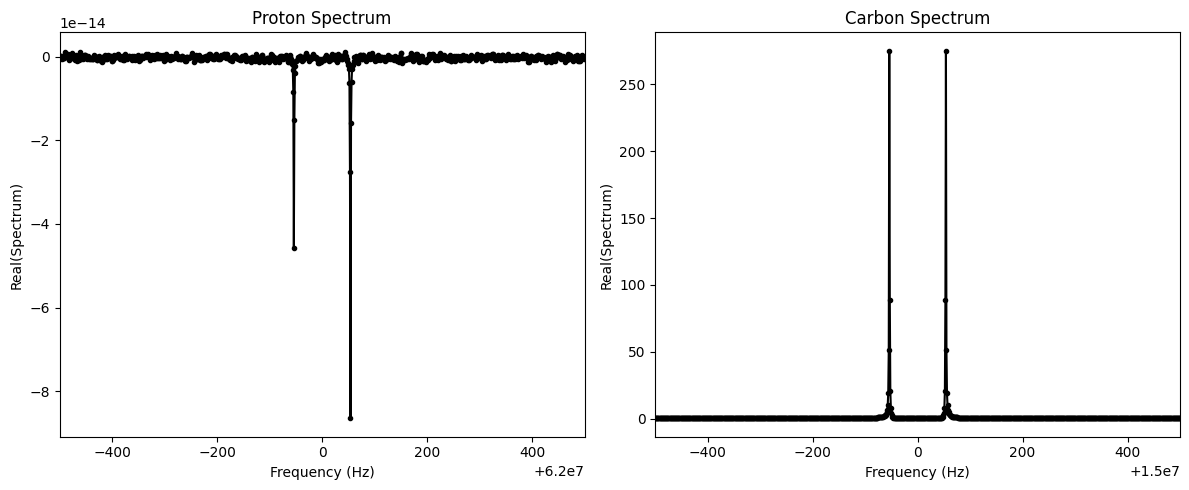

In [830]:
    # Create a time axis up to 1s (based on your comment that you need a longer detection window).
t_array_long = np.linspace(0, 1.0, 2048)

    # T2 for a 1 Hz linewidth (1/pi seconds ~ 0.3183 s).
T2_1Hz = 1 / np.pi

simulate_and_plot_spectra( tensor(-Ix,E)+tensor(E,Iz), t_array_long, T2=T2_1Hz, freq_range=500)

### Controlled Gates:

In [831]:
# start by defining CZ gate:

CZgate=(-1j * np.pi/4 * tensor(sigmaz(),sigmaz())).expm() * p1z.dag() * p2z.dag() * sq2/(1+j)
# cldisp(CZgate)

In [832]:
# CNOT:
CNOT=p2y*CZgate*p2y.dag()
cldisp(CNOT)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1. -0.  0.  0.]
 [-0.  1.  0.  0.]
 [ 0.  0.  0.  1.]
 [ 0.  0.  1. -0.]]

In [833]:
(obsC * CNOT * rho0 * CNOT.dag()).ptrace(0).diag()
cldisp(CNOT * rho0 * CNOT.dag())

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5. -0.  0.  0.]
 [-0.  3.  0.  0.]
 [ 0.  0. -5.  0.]
 [ 0.  0.  0. -3.]]

In [834]:
(obsC * CNOT * rho0 * CNOT.dag()).ptrace(1).diag()

array([0., 0.])

In [835]:
# CNOTapx:

CNOTapx=p2x*uzz*p2y*sq2/(1-j)
cldisp(CNOTapx)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.+0.j -0.-0.j  0.+0.j  0.+0.j]
 [ 0.-0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]]

In [836]:
(obsH * CNOTapx * rho0 * CNOTapx.dag()).ptrace(1).diag()

array([10.,  6.])

In [837]:
(obsC * CNOTapx * rho0 * CNOTapx.dag()).ptrace(0).diag()

array([ 2., -2.])

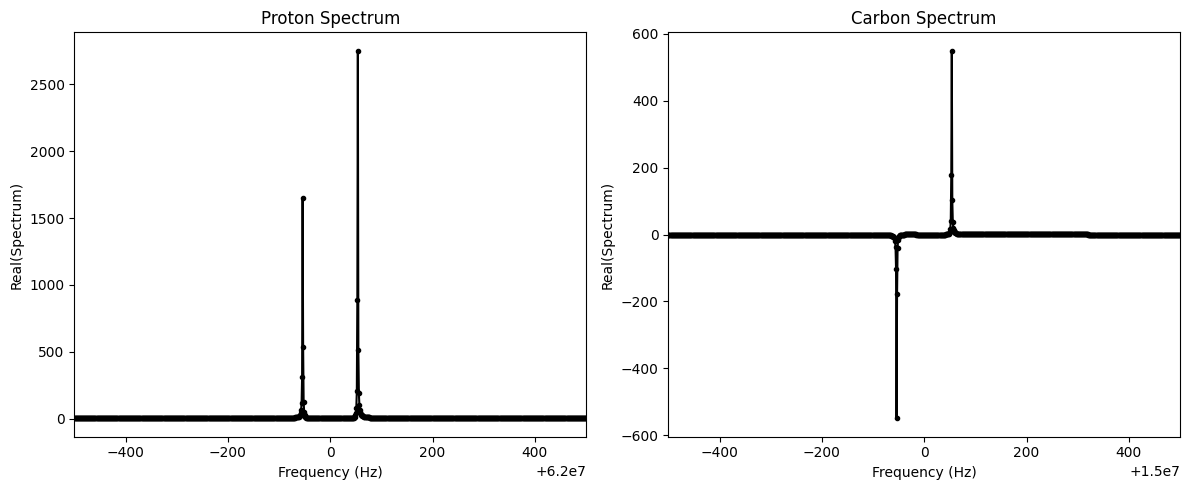

In [838]:
# simulate_and_plot_spectra(CNOTapx * rho0 * CNOTapx.dag(), t_array_long, T2=T2_1Hz, freq_range=500)
simulate_and_plot_spectra(CNOT * rho0 * CNOT.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

In [839]:
CNOTapxH=p1x*uzz*p1y*sq2/(1-j)
cldisp(CNOTapxH)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.+0.j  0.+0.j -0.-0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.-0.j  0.+0.j  0.+1.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]]

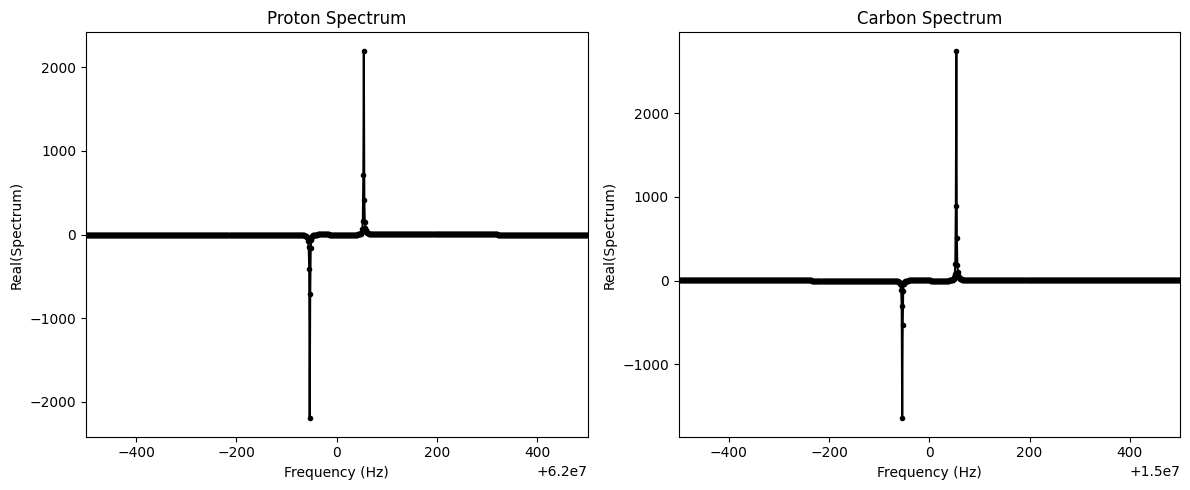

In [840]:
simulate_and_plot_spectra(CNOTapxH * rho0 * CNOTapxH.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

In [841]:
# CNOT:
CNOTH=p1y*CZgate*p1y.dag()
cldisp(CNOTH)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0. -0.  0.]
 [ 0.  0.  0.  1.]
 [-0.  0.  1.  0.]
 [ 0.  1.  0. -0.]]

## Here's what we expect to see when applying CNOT/CNOTH

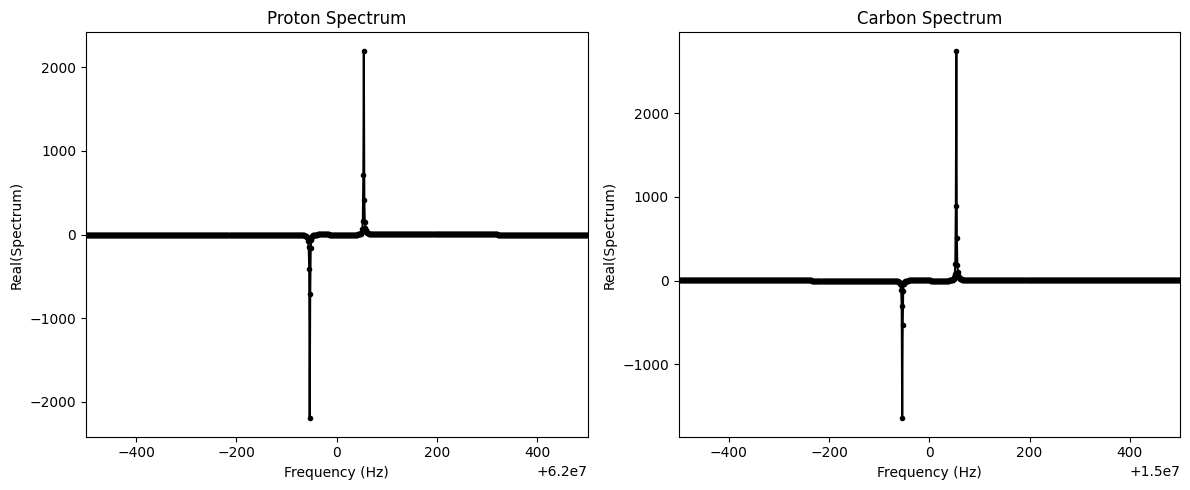

In [842]:
simulate_and_plot_spectra(CNOTH * rho0 * CNOTH.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

### Permutations:

In [843]:
# Image(filename='ppgpermts.png',  width=600, height=100)

In [844]:
# p1= p2y * uzz * p2x * p1y * uzz * p1x
p1 = CNOT*CNOTH
cldisp(p1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1. -0. -0. -0.]
 [-0.  0.  0.  1.]
 [-0.  1.  0. -0.]
 [-0. -0.  1.  0.]]

In [845]:
# p2= p1y * uzz * p2y * p1x * uzz * p2x
p2 = CNOTH*CNOT
cldisp(p2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1. -0. -0. -0.]
 [-0.  0.  1. -0.]
 [-0.  0.  0.  1.]
 [-0.  1. -0.  0.]]

## Pseudopure

X on nothing

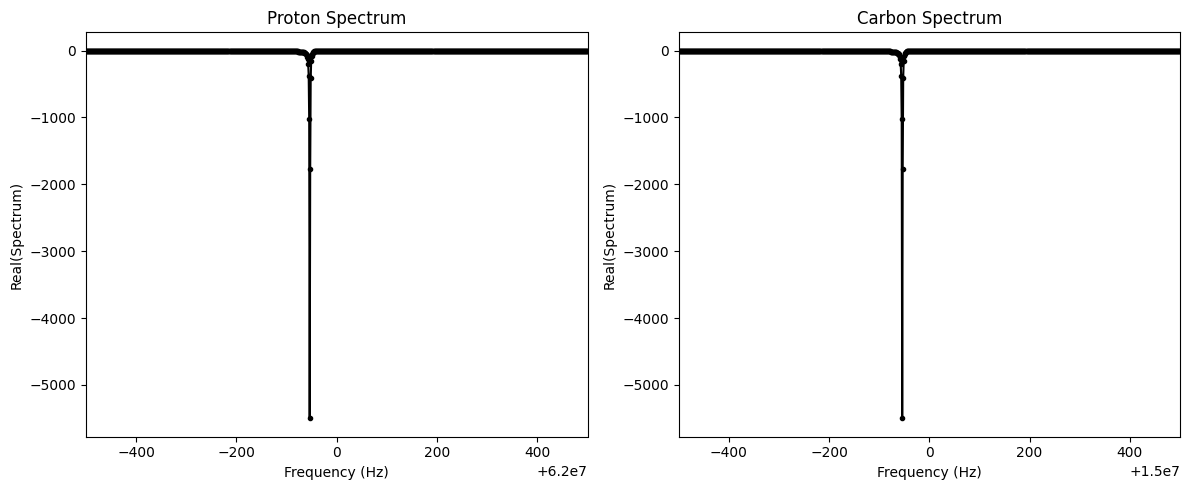

In [887]:
simulate_and_plot_spectra(X2*X1*rho0*(X2*X1).dag() + X2*X1*p1*rho0*p1.dag()*(X2*X1).dag() + X2*X1*p2*rho0*p2.dag()*(X2*X1).dag(), t_array_long, T2=T2_1Hz, freq_range=500)
# simulate_and_plot_spectra(rho0, t_array_long, T2=T2_1Hz, freq_range=500)

X on first

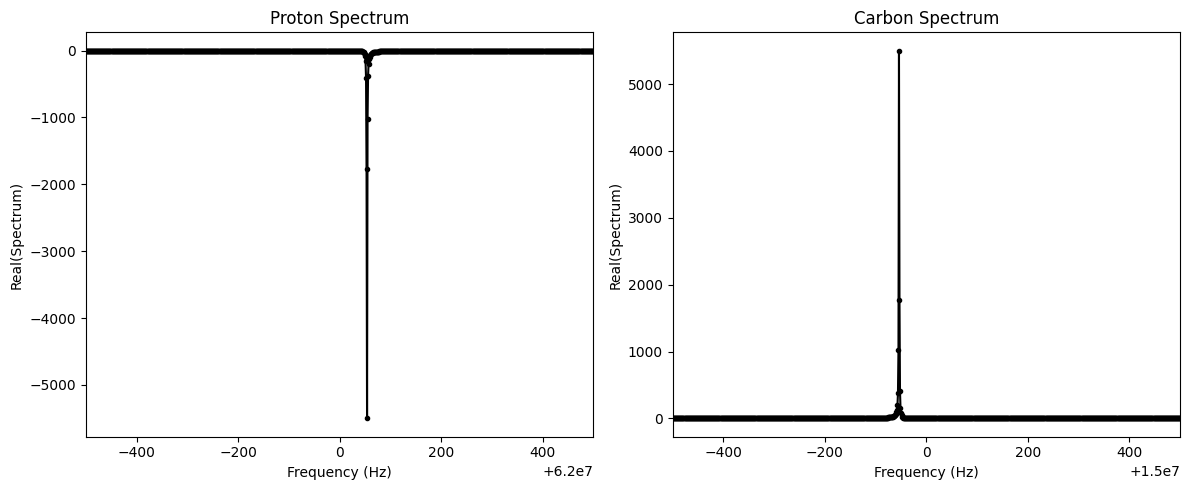

In [847]:
simulate_and_plot_spectra(X1*rho0*X1.dag() + X1*p1*rho0*p1.dag()*X1.dag() + X1*p2*rho0*p2.dag()*X1.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

Hadamard on 1H

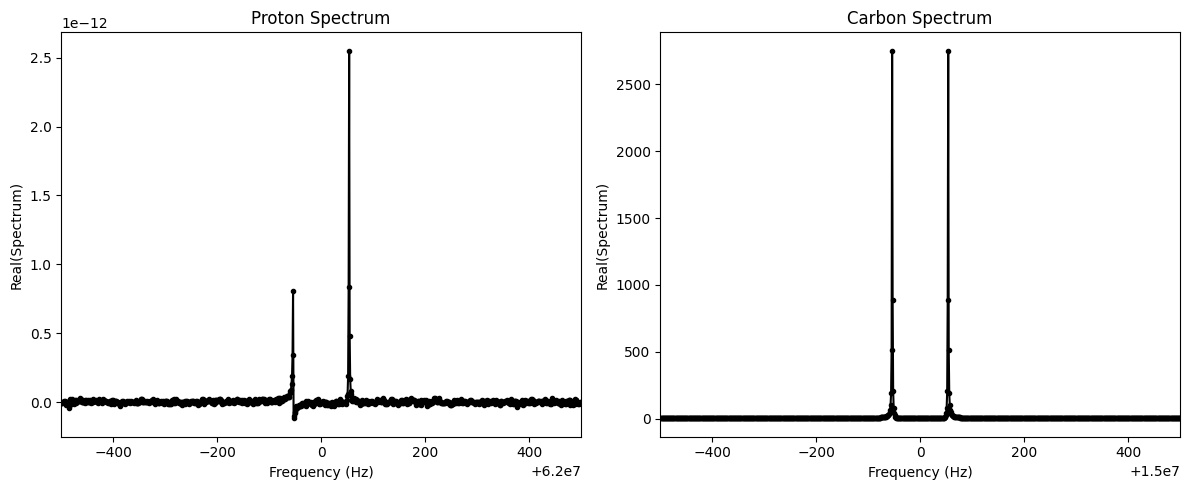

In [848]:
simulate_and_plot_spectra(H1*rho0*H1.dag() + H1*p1*rho0*p1.dag()*H1.dag() + H1*p2*rho0*p2.dag()*H1.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

## CNOT

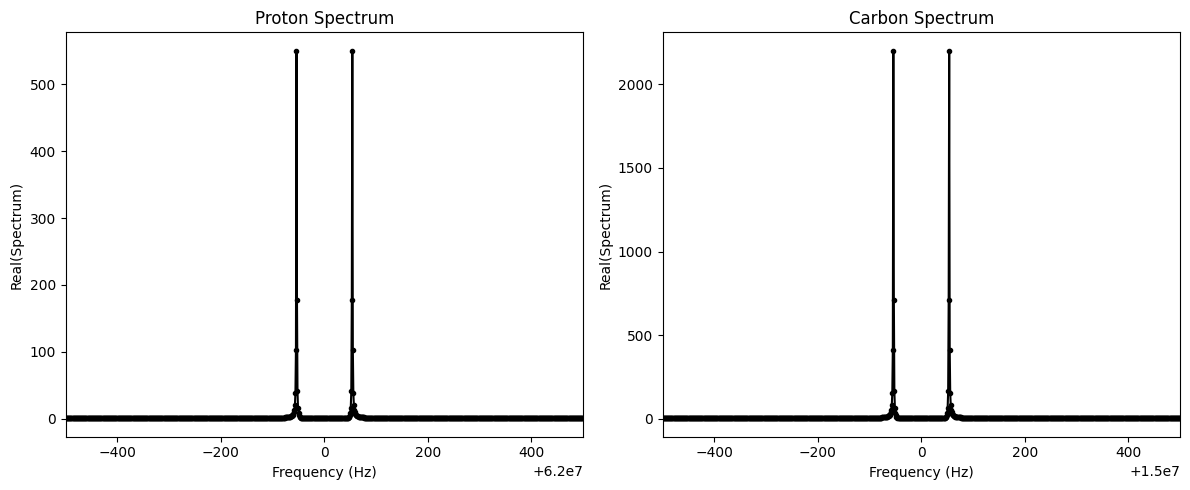

In [849]:
# simulate_and_plot_spectra(CNOTH*X1*X2*rho0*X1*X2*CNOTH.dag() + CNOTH*X1*X2*p1*rho0*p1.dag()*X1*X2*CNOTH.dag() + CNOTH*X1*X2*p2*rho0*p2.dag()*X1*X2*CNOTH.dag(), t_array_long, T2=T2_1Hz, freq_range=500)
simulate_and_plot_spectra(CNOT*p2*rho0*p2.dag()*CNOT.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

# DJ

In [850]:
DJ = H1*CNOT*H1*H2*X2

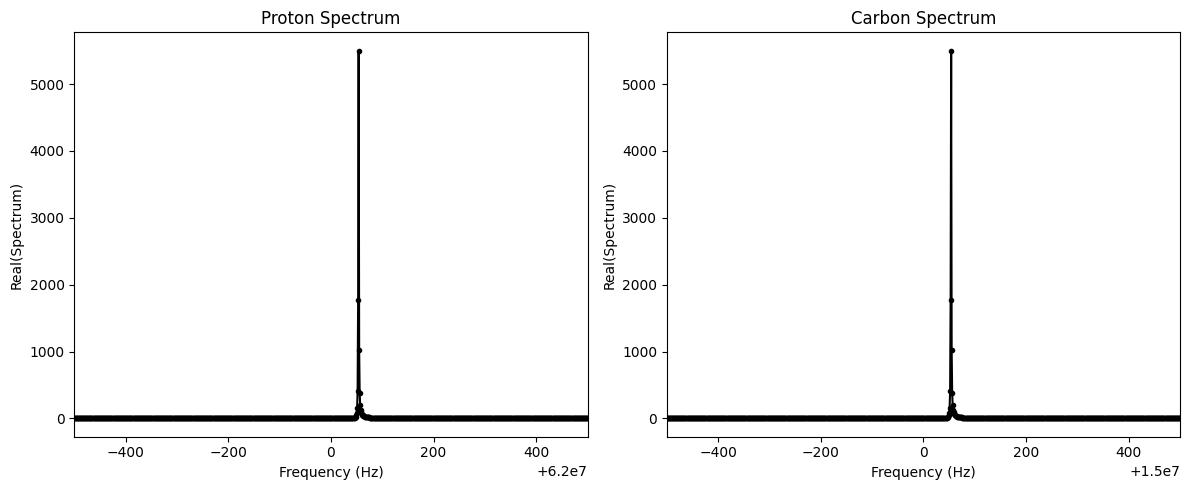

In [851]:
simulate_and_plot_spectra(CNOTH*rho0*CNOTH.dag() + CNOTH*p1*rho0*p1.dag()*CNOTH.dag() + CNOTH*p2*rho0*p2.dag()*CNOTH.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

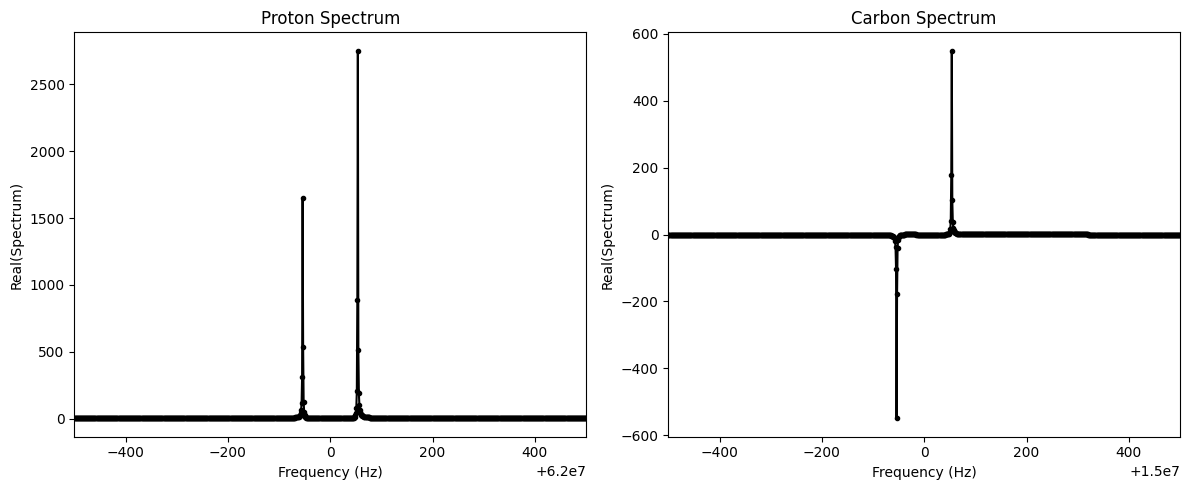

In [852]:
simulate_and_plot_spectra(CNOT*rho0*CNOT.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

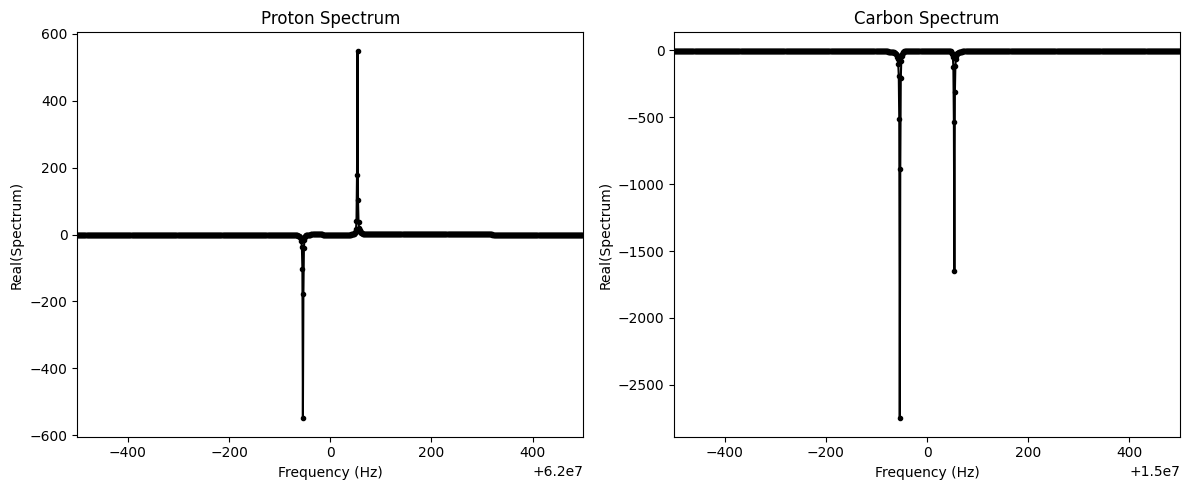

In [853]:
simulate_and_plot_spectra( p1x*p1x*p1 * rho0 * p1.dag()*p1x*p1x, t_array_long, T2=T2_1Hz, freq_range=500)

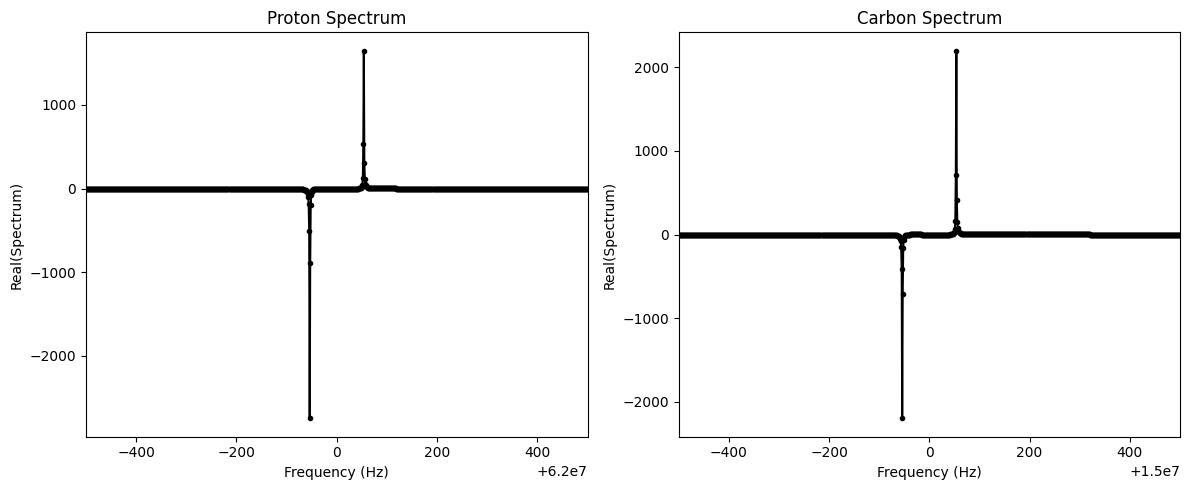

In [854]:
simulate_and_plot_spectra( p2x*p2x*p1x*p1x*p2 * rho0 * p2.dag()*p2x*p2x*p1x*p1x, t_array_long, T2=T2_1Hz, freq_range=500)


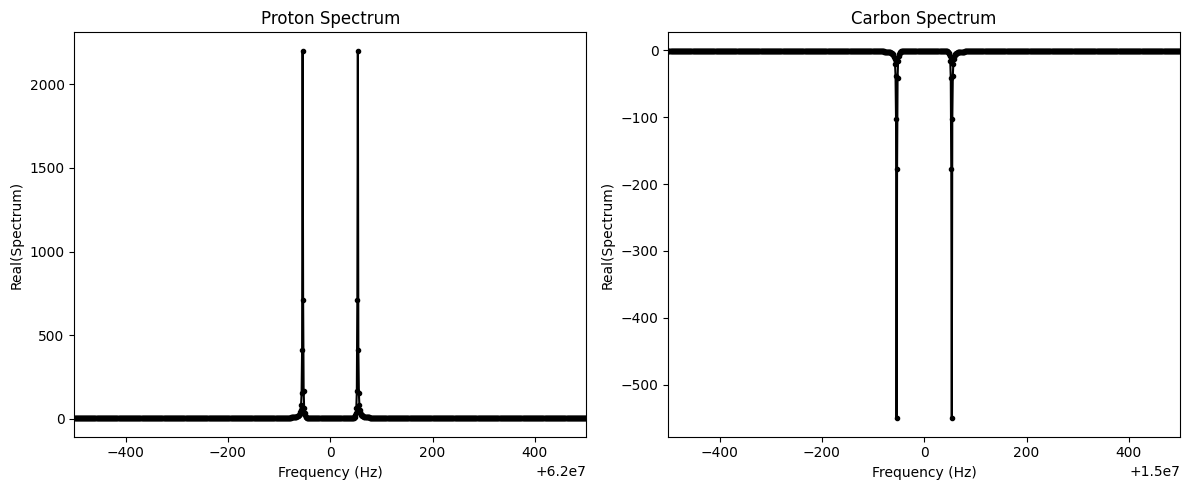

In [855]:
simulate_and_plot_spectra( p1x*p1x*rho0*p1x*p1x , t_array_long, T2=T2_1Hz, freq_range=500)

### Y-first permutations

In [856]:
p1= p1x * uzz * p1y * p2x * uzz * p2y
cldisp(p1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.-1.j  0.+0.j -0.-0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j -0.-0.j]
 [-0.-0.j -0.+0.j  0.+0.j -0.-1.j]
 [-0.-0.j  1.+0.j  0.-0.j  0.-0.j]]

In [857]:
p2= p2x * uzz * p2y * p1x * uzz * p1y
cldisp(p2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.-1.j -0.-0.j  0.-0.j  0.+0.j]
 [-0.-0.j  0.+0.j -0.+0.j  0.-1.j]
 [ 0.-0.j -1.+0.j  0.+0.j -0.-0.j]
 [-0.-0.j  0.-0.j  1.+0.j  0.-0.j]]

In [858]:
(obsH * p1 * rho0 * p1.dag()).ptrace(1).diag()

array([10., -6.])

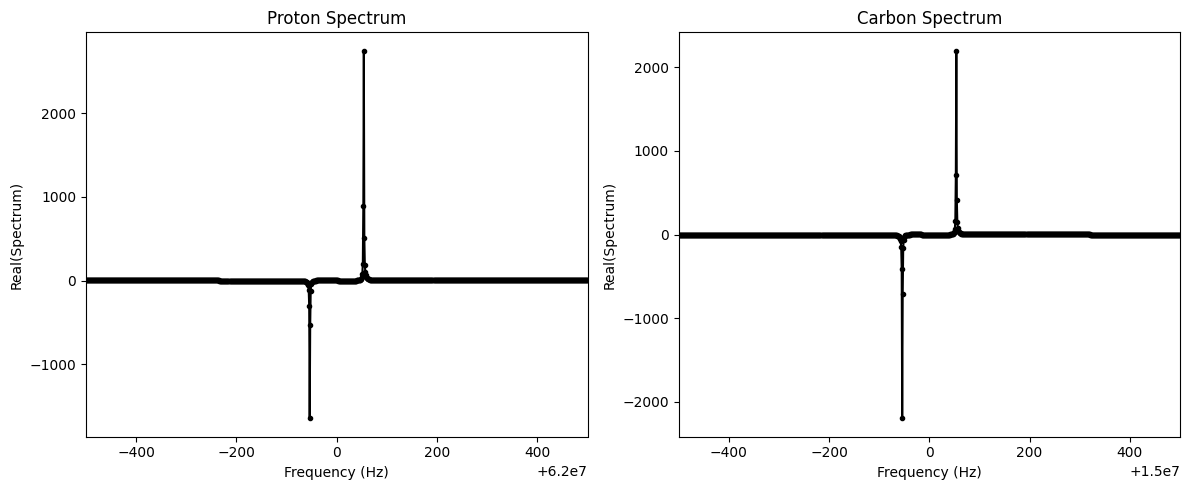

In [859]:
simulate_and_plot_spectra( p1 * rho0 * p1.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

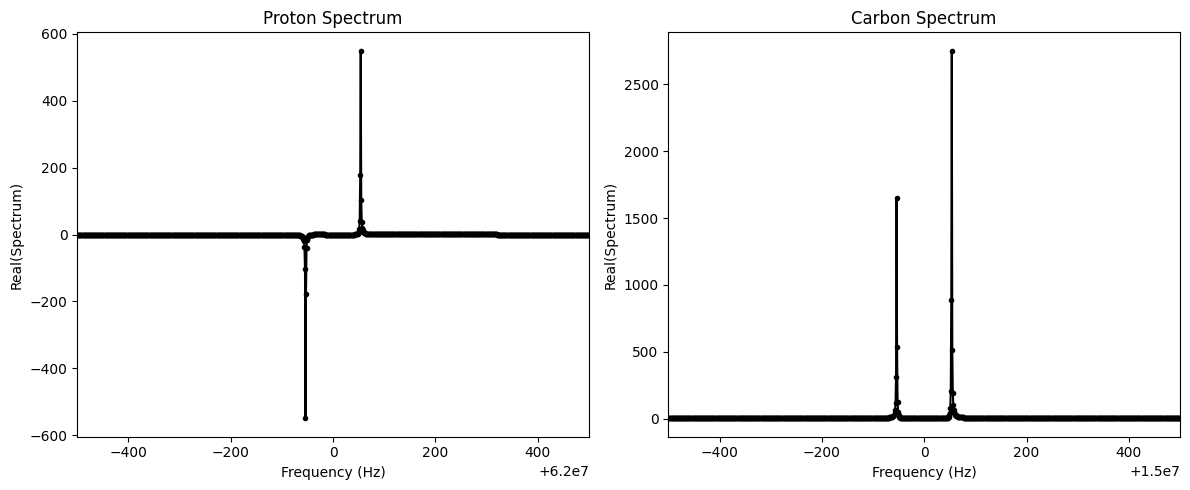

In [860]:
simulate_and_plot_spectra( p2 * rho0 * p2.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

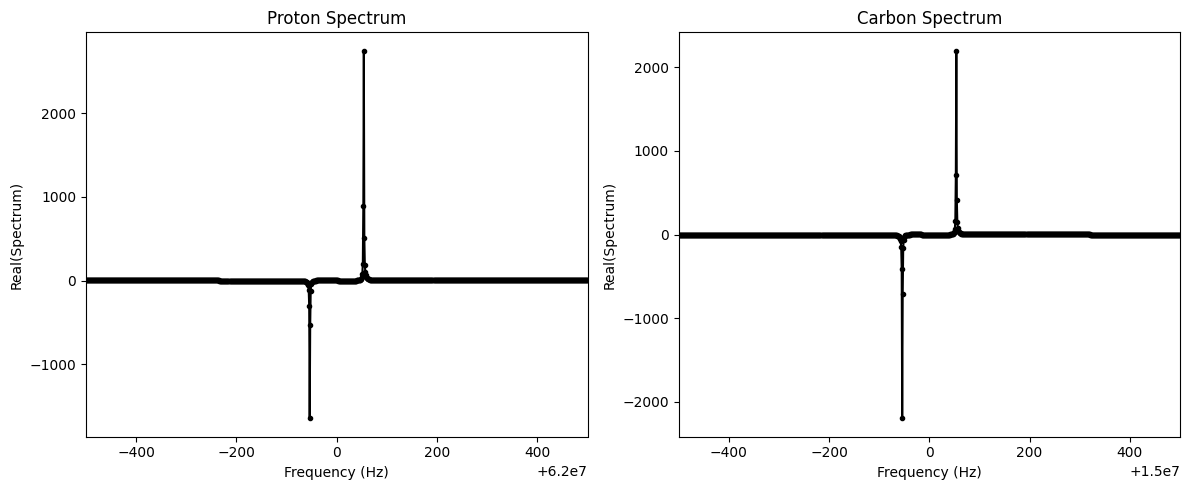

In [861]:
simulate_and_plot_spectra( p1 * rho0 * p1.dag(), t_array_long, T2=T2_1Hz, freq_range=500)

In [862]:
(obsH * p2 * rho0 * p2.dag()).ptrace(1).diag()

array([ 2., -2.])

In [863]:
(obsH * (rho0 + p1 * rho0 * p1.dag()+ p2 * rho0 * p2.dag() )).ptrace(1).diag()

array([20.,  0.])

In [864]:
(obsC * (rho0 + p1 * rho0 * p1.dag()+ p2 * rho0 * p2.dag() )).ptrace(0).diag()

array([20., -0.])

In [865]:
CZgate=(-1j*np.pi/4*tensor(sigmaz(),sigmaz())).expm()*p1z*p2z/np.sqrt(2)
cldisp(CZgate)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.5-0.5j  0. +0.j   0. +0.j   0. +0.j ]
 [ 0. +0.j   0.5+0.5j  0. +0.j   0. +0.j ]
 [ 0. +0.j   0. +0.j   0.5+0.5j  0. +0.j ]
 [ 0. +0.j   0. +0.j   0. +0.j   0.5+0.5j]]

In [866]:
(-1j*np.pi/2*tensor(sigmaz(),sigmaz())).expm()/np.sqrt(2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.-0.71j  0.+0.j    0.+0.j    0.+0.j  ]
 [-0.+0.j   -0.+0.71j -0.+0.j   -0.+0.j  ]
 [-0.+0.j   -0.+0.j   -0.+0.71j -0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.-0.71j]]

In [867]:
cldisp(p2y*(-1j*np.pi/4*tensor(sigmaz(),sigmaz())).expm()*p1z*p2z*p2y/np.sqrt(2)*2/(1-j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.-1.j -0.+0.j  0.+0.j  0.+0.j]
 [ 0.-0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+1.j  0.+0.j]]

## appliable CNOT here

In [868]:
# CNOT1=p2z.dag()*p1z*p2x*uzz*p2y/np.sqrt(2)*2/(1-j)
CNOT1 = p2y*p2x*p2y.dag() * p1y.dag()*p1x*p1y * p2x * uzz * p2y/np.sqrt(2)*2/(1-j)
cldisp(CNOT1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0. -0.]
 [-0.  1. -0. -0.]
 [-0. -0. -0.  1.]
 [-0. -0.  1.  0.]]

In [869]:
CNOT2=np.exp(j*np.pi/4)*(j*np.pi/4*tensor(qeye(2),sigmax())).expm()*(j*np.pi/4*tensor(sigmaz(),qeye(2))).expm()*(-j*np.pi/4*tensor(sigmaz(),sigmax())).expm()
cldisp(CNOT2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -0.+1.j]
 [ 0.+0.j  0.+0.j  0.+1.j  0.+0.j]]

In [870]:
CNOT3=np.exp(j*np.pi/4) * (j*np.pi/4*tensor(qeye(2),sigmax())).expm() * (j*np.pi/4*tensor(sigmaz(),qeye(2))).expm() * (-j*np.pi/4*tensor(qeye(2),sigmay())).expm() * (-j*np.pi/4*tensor(sigmaz(),sigmaz())).expm() * (j*np.pi/4*tensor(qeye(2),sigmay())).expm()
cldisp(CNOT3)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j -0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+1.j]
 [ 0.+0.j  0.+0.j -0.+1.j  0.+0.j]]

In [871]:
cldisp(p1z.dag()*p2x.dag()*p2y*uzz*p2y.dag()/np.sqrt(2)*2/(1+j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1. -0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0. -0.  1.]
 [ 0.  0.  1. -0.]]

In [872]:
cldisp(p2x.dag()*p2y*uzz*p2y.dag()/(1))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.-0.j -0.-0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+1.j]
 [ 0.+0.j  0.+0.j -0.+1.j  0.-0.j]]

###### CNOTappx=p2y.dag()*CZgate*p2y.dag()/(-1+j)*2
cldisp(CNOTappx)

In [873]:
p1z.dag()*p2z.dag()*uzz/np.sqrt(2)*2/(1-j)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]]

In [874]:
cldisp(p2y*uzz*p2x.dag()/np.sqrt(2) * 2/(1-j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.+0.j -0.-0.j  0.+0.j  0.+0.j]
 [-0.+0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.-0.j]
 [ 0.+0.j  0.+0.j  0.+1.j  0.+0.j]]

In [875]:
cldisp(p2y.dag()*uzz*p2x*np.sqrt(-j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.-1.j -0.-0.j  0.+0.j  0.+0.j]
 [-0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.-0.j  0.-1.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.-0.j]]

In [876]:
cldisp(p2y*uzz*p2x.dag()*p1z.dag()*p2z.dag()/np.sqrt(2)*2/(1-j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+1.j -0.-0.j  0.+0.j  0.+0.j]
 [-0.-0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -0.+1.j]
 [ 0.+0.j  0.+0.j -0.+1.j  0.-0.j]]

In [877]:
H = qutip.Qobj(np.array([[1, 1],[1, -1]])*1/np.sqrt(2))
H1=tensor(qeye(2),H)
H0=tensor(H, qeye(2))
DJ_0 = tensor(H,H)
DJ_1 = H1

cldisp(H0)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.71  0.    0.71  0.  ]
 [ 0.    0.71  0.    0.71]
 [ 0.71  0.   -0.71 -0.  ]
 [ 0.    0.71 -0.   -0.71]]

In [878]:
cldisp(p2y.dag()*uzz*p2x/np.sqrt(2j))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.  -0.71j -0.  -0.j    0.  +0.j    0.  +0.j  ]
 [-0.  +0.j    0.71+0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  -0.j    0.  -0.71j]
 [ 0.  +0.j    0.  +0.j   -0.71+0.j    0.  +0.j  ]]

In [879]:
(-1j*np.pi/4*tensor(sigmay(),qeye(2))).expm()

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.71  0.   -0.71  0.  ]
 [ 0.    0.71  0.   -0.71]
 [ 0.71  0.    0.71  0.  ]
 [ 0.    0.71  0.    0.71]]

In [880]:
A = np.matrix([[5,0,0,0],
               [0,3,0,0],
               [0,0,-3,0],
               [0,0,0,-5]])
A = np.matrix(qutip.Qobj(A, dims=[[2, 2],[2, 2]]))

In [881]:
A.shape

(1, 1)

In [882]:
p2x/np.sqrt(2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.5+0.j  0. -0.5j 0. +0.j  0. +0.j ]
 [0. -0.5j 0.5+0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0.5+0.j  0. -0.5j]
 [0. +0.j  0. +0.j  0. -0.5j 0.5+0.j ]]

In [883]:
x90H  = tensor(rx(pi/2),E)
x90C  = tensor(E,rx(pi/2))

HH = tensor(ry(-pi/4),E)*tensor(rx(pi),E)*tensor(ry(pi/4),E)
HC = tensor(E, ry(-pi/4))*tensor(E, rx(pi))*tensor(E, ry(pi/4))
CNOT01 = CNOT
CNOT10 = CNOTH
XH = tensor(rx(pi),E)
XC = tensor(E, rx(pi))

# Thermal = HH@XC@HC@HH@XC

# cldisp(Thermal@A@Thermal.conj().T)

In [884]:
2*snot()/np.sqrt(2)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  1.]
 [ 1. -1.]]

In [885]:
(-1j*np.pi/4*(sigmax()+sigmaz())/np.sqrt(2)).expm()/np.sqrt(2)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.5-0.35j -0. -0.35j]
 [-0. -0.35j  0.5+0.35j]]